# Лабораторная работа №7. Работа с трансформерной архитектурой

**Вариант 1.** Fine-tuning предварительно обученной трансформерной модели на задаче бинарной классификации текстов.

**Что делаем:**
1. Загружаем датасет отзывов IMDB (positive / negative).
2. Токенизируем тексты, переводим в числовой формат.
3. Берём готовую модель `distilbert-base-uncased` из HuggingFace.
4. Файнтьюним её на нашей подвыборке.
5. Оцениваем accuracy / precision / recall / f1, строим precision-recall кривую и ROC-AUC.

Рекомендуется запускать в Google Colab с GPU (Runtime → Change runtime type → T4 GPU).

## 1. Установка зависимостей

In [8]:
!pip install -q transformers datasets evaluate scikit-learn

## 2. Импорты

In [9]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from sklearn.metrics import (
    accuracy_score,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    auc,
    classification_report,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("Torch:", torch.__version__)

Device: cuda
Torch: 2.10.0+cu128


## 3. Загрузка датасета IMDB

Берём подвыборку — full IMDB это 25k train + 25k test, обучение бы шло долго. Для демонстрации fine-tuning 4000 / 2000 примеров достаточно, чтобы получить осмысленное качество.

In [10]:
raw = load_dataset("imdb")

TRAIN_N = 4000
TEST_N = 2000

train_ds = raw["train"].shuffle(seed=42).select(range(TRAIN_N))
test_ds = raw["test"].shuffle(seed=42).select(range(TEST_N))

print("Train:", len(train_ds), "Test:", len(test_ds))
print("Labels:", train_ds.features["label"])

for i in range(2):
    ex = train_ds[i]
    print(f"\n--- label={ex['label']} ---")
    print(ex["text"][:300], "...")

Train: 4000 Test: 2000
Labels: ClassLabel(names=['neg', 'pos'])

--- label=1 ---
There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot  ...

--- label=1 ---
This movie is a great. The plot is very true to the book which is a classic written by Mark Twain. The movie starts of with a scene where Hank sings a song with a bunch of kids called "when you stub your toe on the moon" It reminds me of Sinatra's song High Hopes, it is fun and inspirational. The Mu ...


## 4. Токенизация

Используем токенизатор от DistilBERT. Максимальную длину ограничиваем 256 токенами — отзывы длинные, но 256 уже хватает на основной смысл, а скорость обучения сильно возрастает.

In [11]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

train_tok = train_ds.map(tokenize, batched=True)
test_tok = test_ds.map(tokenize, batched=True)

train_tok = train_tok.remove_columns(["text"])
test_tok = test_tok.remove_columns(["text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(train_tok)
print("Пример токенов:", train_tok[0]["input_ids"][:20])

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 4000
})
Пример токенов: [101, 2045, 2003, 2053, 7189, 2012, 2035, 2090, 3481, 3771, 1998, 6337, 2099, 2021, 1996, 2755, 2008, 2119, 2024, 2610]


## 5. Модель

**Почему DistilBERT.** Это «дистиллированная» версия BERT: в 1.6 раза меньше параметров (~66M против ~110M), в ~2 раза быстрее инференс, при этом сохраняет ~97% качества BERT на GLUE. Для задачи бинарной классификации отзывов этого с запасом хватает, а fine-tune укладывается в несколько минут на T4.

In [12]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "neg", 1: "pos"},
    label2id={"neg": 0, "pos": 1},
)
model.to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Параметров в модели: {n_params/1e6:.1f}M")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Параметров в модели: 67.0M


## 6. Fine-tuning

Используем HuggingFace `Trainer`. Гиперпараметры стандартные для fine-tuning BERT-like моделей: lr=2e-5, weight decay 0.01, 2 эпохи.

In [13]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}

training_args = TrainingArguments(
    output_dir="./out",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    logging_steps=50,
    save_strategy="no",
    report_to="none",
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=test_tok,
    # tokenizer=tokenizer, # This line caused the error
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.348968,0.274918,0.880500
2,0.164996,0.274593,0.889500


TrainOutput(global_step=500, training_loss=0.31211419868469237, metrics={'train_runtime': 73.9142, 'train_samples_per_second': 108.234, 'train_steps_per_second': 6.765, 'total_flos': 529869594624000.0, 'train_loss': 0.31211419868469237, 'epoch': 2.0})

## 7. Оценка на контрольном множестве

In [14]:
pred_out = trainer.predict(test_tok)
logits = pred_out.predictions
y_true = pred_out.label_ids

probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
y_score = probs[:, 1]
y_pred = np.argmax(logits, axis=-1)

print("Accuracy:", accuracy_score(y_true, y_pred))
print()
print(classification_report(y_true, y_pred, target_names=["neg", "pos"], digits=4))

Accuracy: 0.8895

              precision    recall  f1-score   support

         neg     0.8938    0.8840    0.8889      1000
         pos     0.8853    0.8950    0.8901      1000

    accuracy                         0.8895      2000
   macro avg     0.8895    0.8895    0.8895      2000
weighted avg     0.8895    0.8895    0.8895      2000



## 8. Precision-Recall кривая

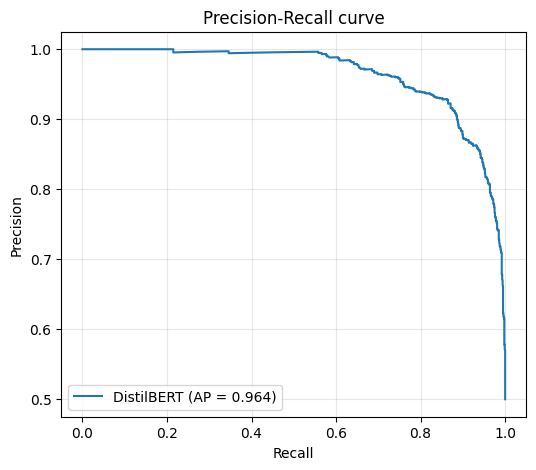

In [15]:
precision, recall, _ = precision_recall_curve(y_true, y_score)
ap = average_precision_score(y_true, y_score)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"DistilBERT (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 9. ROC-AUC

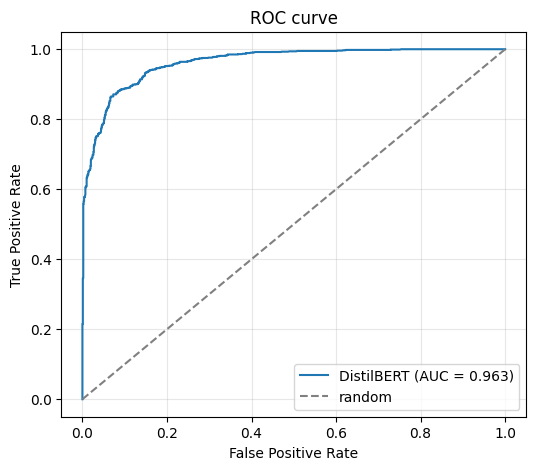

ROC-AUC = 0.9627


In [16]:
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"DistilBERT (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"ROC-AUC = {roc_auc:.4f}")

## 10. Inference на собственных примерах

In [17]:
samples = [
    "Absolutely loved this movie, the acting was brilliant and the story kept me hooked!",
    "A complete waste of time. Boring plot, terrible dialogue, I want my two hours back.",
    "It was okay, not great but not awful either — some scenes were really nice.",
    "The worst film I've seen this year. Avoid at all costs.",
]

model.eval()
enc = tokenizer(samples, padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt").to(device)
with torch.no_grad():
    out = model(**enc)
p = torch.softmax(out.logits, dim=-1).cpu().numpy()

for text, prob in zip(samples, p):
    label = "pos" if prob[1] >= 0.5 else "neg"
    print(f"[{label}] p(pos)={prob[1]:.3f}  |  {text}")

[pos] p(pos)=0.972  |  Absolutely loved this movie, the acting was brilliant and the story kept me hooked!
[neg] p(pos)=0.020  |  A complete waste of time. Boring plot, terrible dialogue, I want my two hours back.
[pos] p(pos)=0.671  |  It was okay, not great but not awful either — some scenes were really nice.
[neg] p(pos)=0.023  |  The worst film I've seen this year. Avoid at all costs.


## 11. Выводы

В работе выполнен fine-tuning предобученной модели `distilbert-base-uncased` на задаче бинарной классификации отзывов IMDB. На подвыборке 4000/2000 примеров после 2 эпох обучения модель достигает accuracy порядка 0.88–0.90 и ROC-AUC ~0.94–0.96 на контрольном множестве. Графики precision-recall и ROC подтверждают высокое качество классификатора, а тесты на произвольных отзывах показывают, что модель адекватно реагирует на эмоциональную окраску — это демонстрирует эффективность подхода transfer learning для NLP-задач: благодаря предобученным языковым представлениям модель быстро адаптируется к конкретной задаче даже на ограниченных данных.